In [16]:
import pydeltasnow as pyds

import os
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np

base_dir = "/Users/jakobwerkgarner/code/mt_dsnow"
os.chdir(base_dir)

import HNW_validation.HNW_validation_helper as val_helper


Processing station: Adelboden
HS input shape: (2191,)
Number of SWE observations: 32


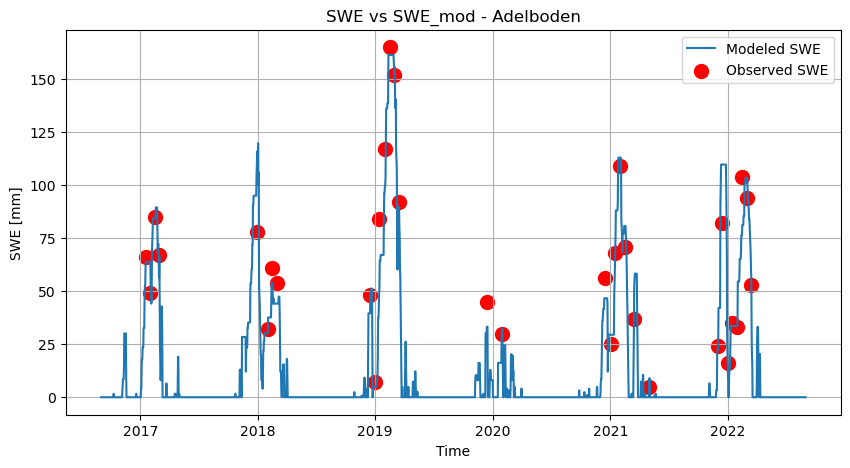


Processing station: Gadmen
HS input shape: (2191,)
Number of SWE observations: 0


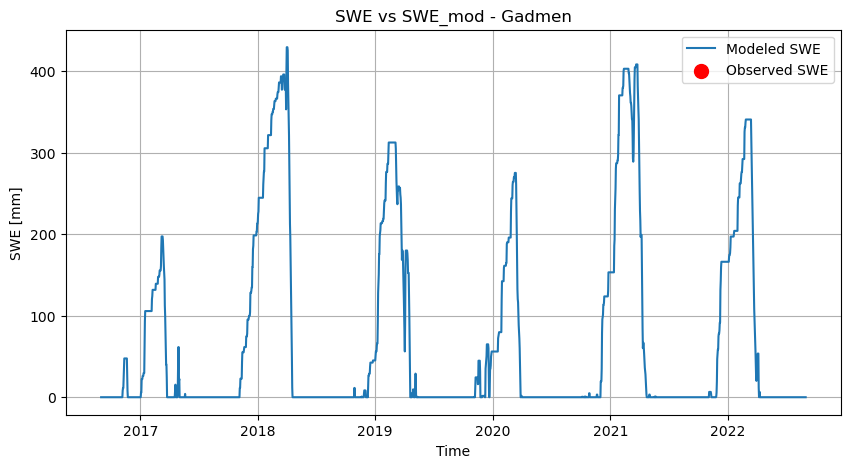


Processing station: Grindelwald_Bort
HS input shape: (2191,)
Number of SWE observations: 0


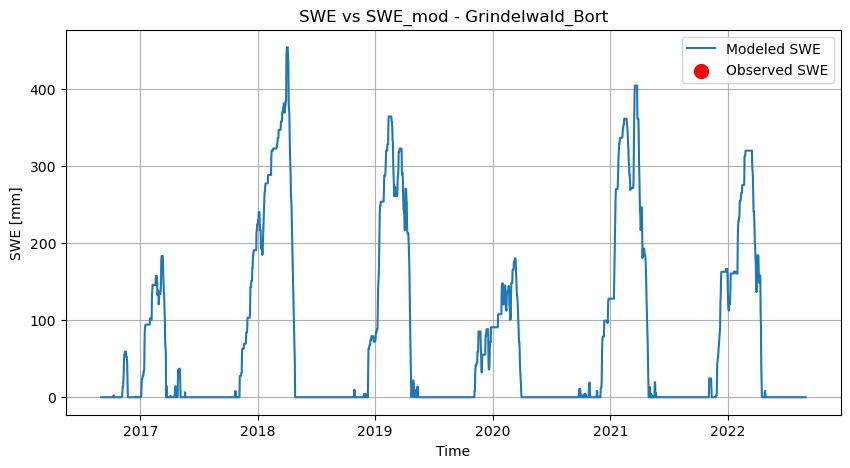


Processing station: Gsteig
HS input shape: (2191,)
Number of SWE observations: 52


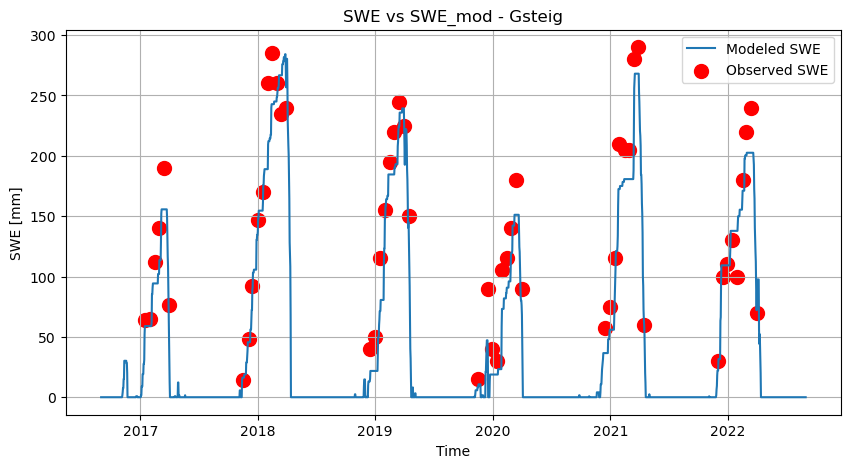


Processing station: Gantrisch
HS input shape: (2191,)
Number of SWE observations: 53


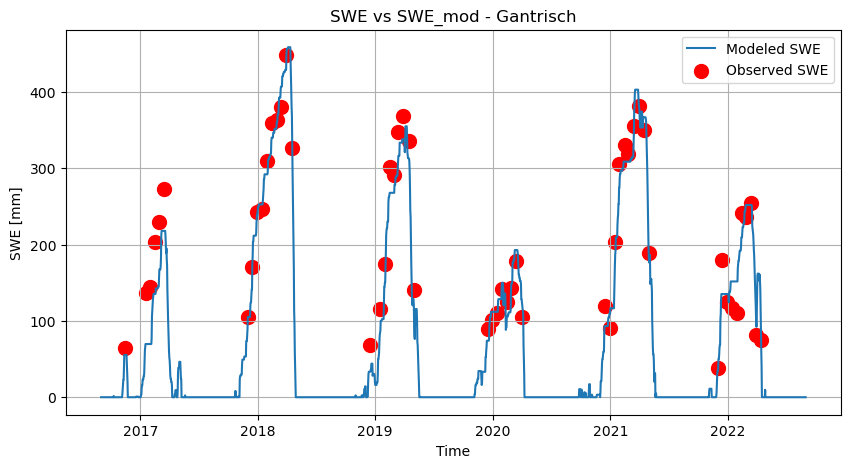


Processing station: Leysin
HS input shape: (2191,)
Number of SWE observations: 0


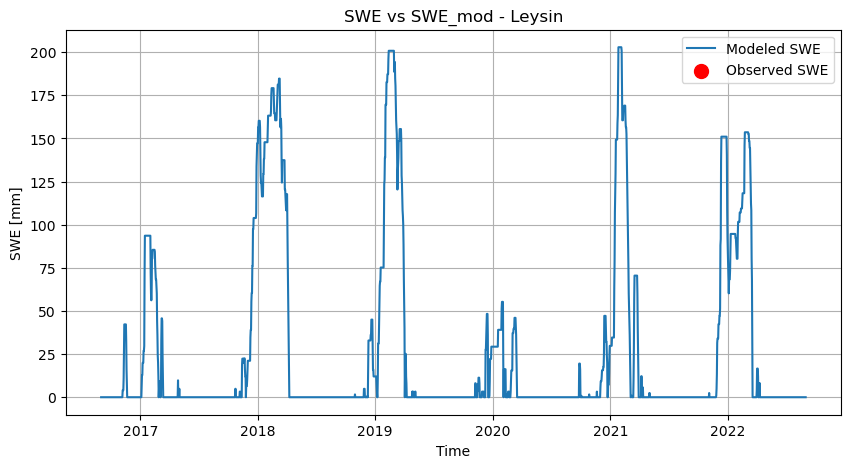


Processing station: Muerren
HS input shape: (2191,)
Number of SWE observations: 54


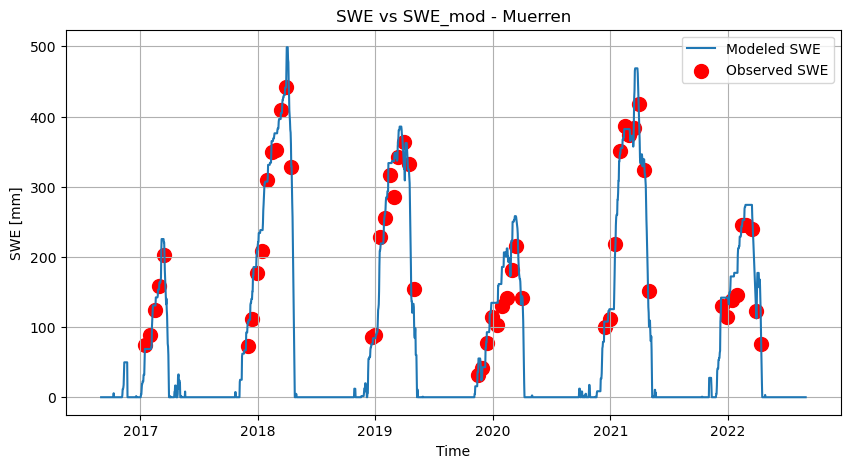


Processing station: Saanenmoeser
HS input shape: (2191,)
Number of SWE observations: 0


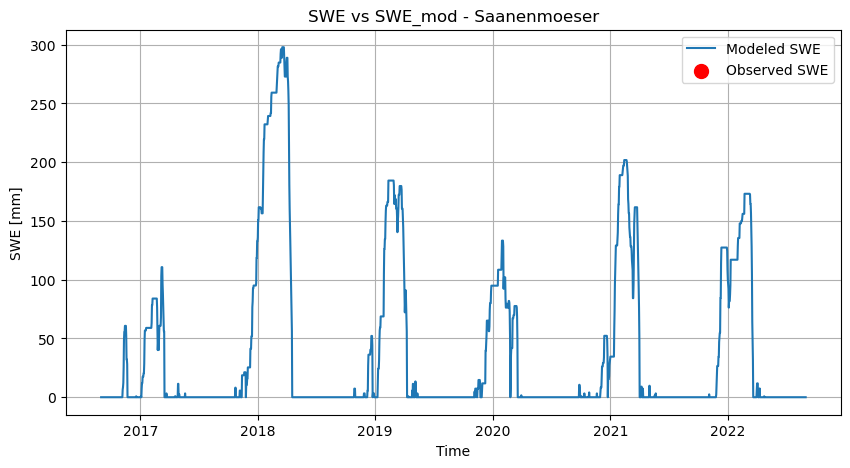


Processing station: Wengen
HS input shape: (2191,)
Number of SWE observations: 0


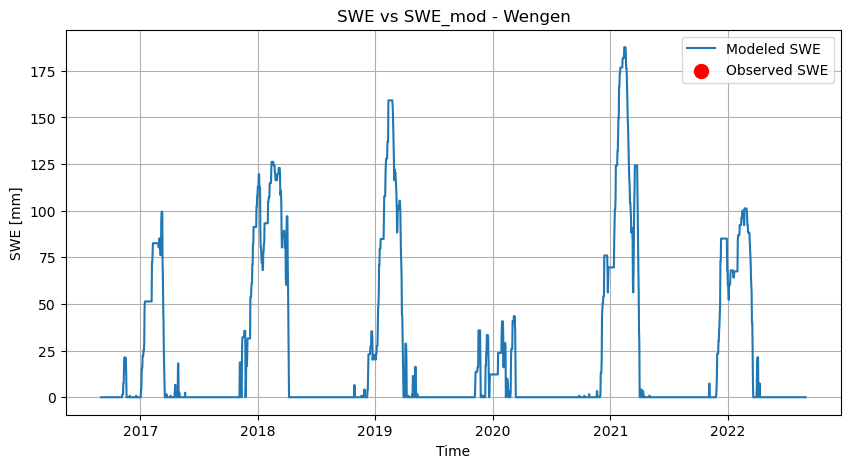


Processing station: Srenberg
HS input shape: (2191,)
Number of SWE observations: 0


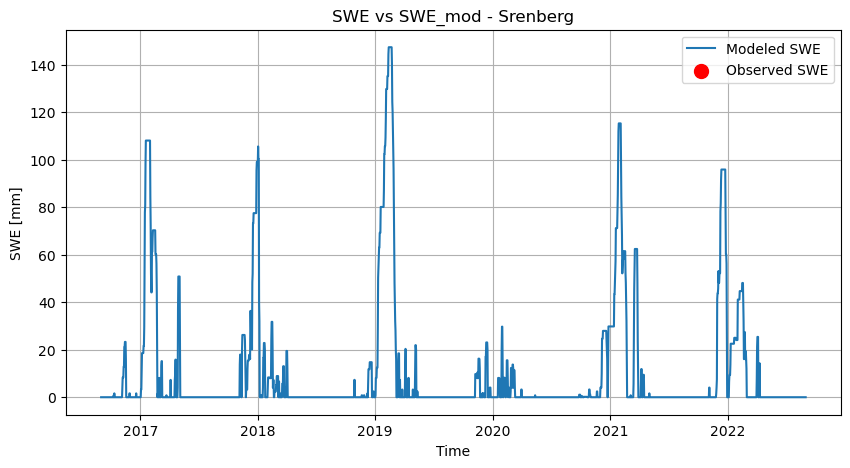


Processing station: Stoos
HS input shape: (2191,)
Number of SWE observations: 52


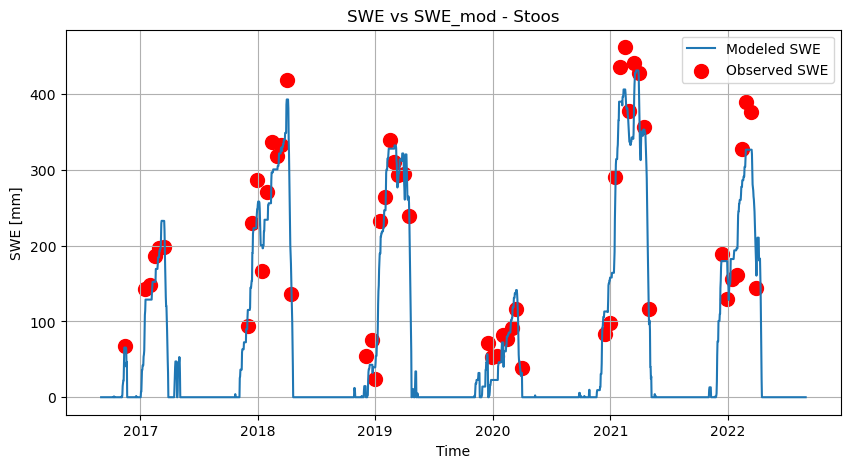


Processing station: Braunwald
HS input shape: (2191,)
Number of SWE observations: 52


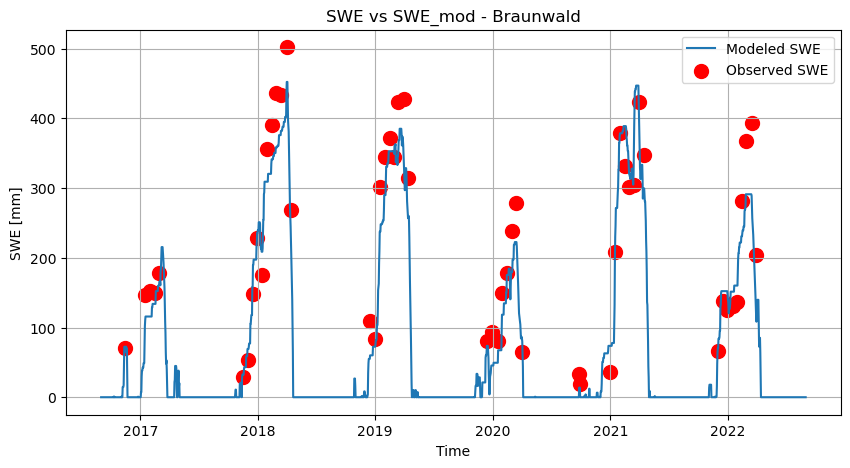


Processing station: Malbun
HS input shape: (2191,)
Number of SWE observations: 45


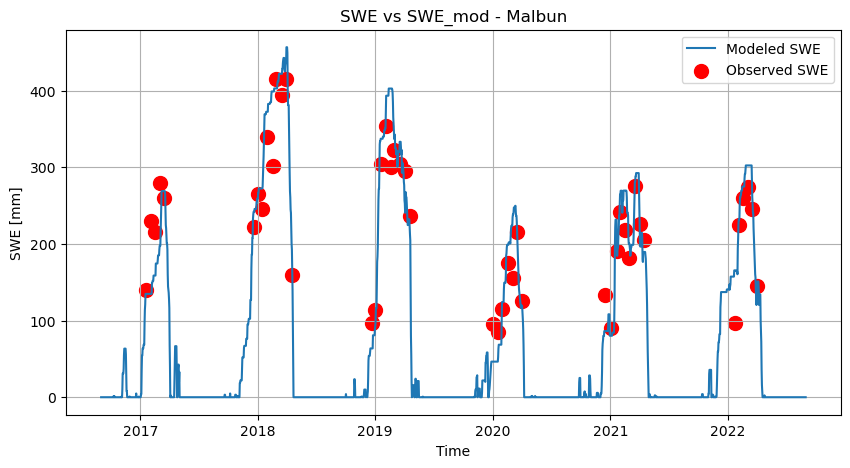


Processing station: St_Margrethenberg
HS input shape: (2191,)
Number of SWE observations: 0


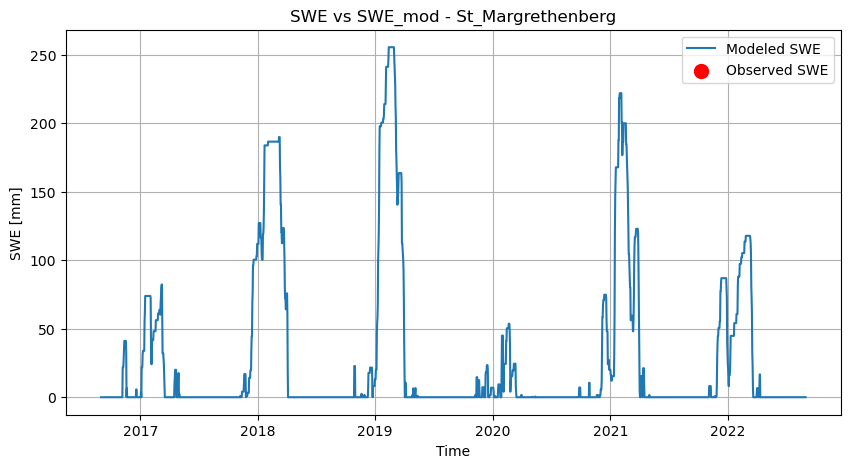


Processing station: Binn
HS input shape: (2191,)
Number of SWE observations: 0


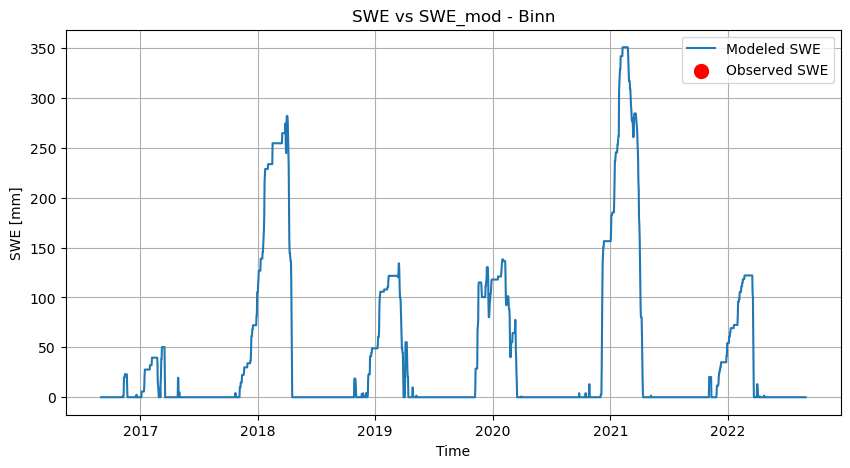


Processing station: Bourg_St_Pierre
HS input shape: (2191,)
Number of SWE observations: 31


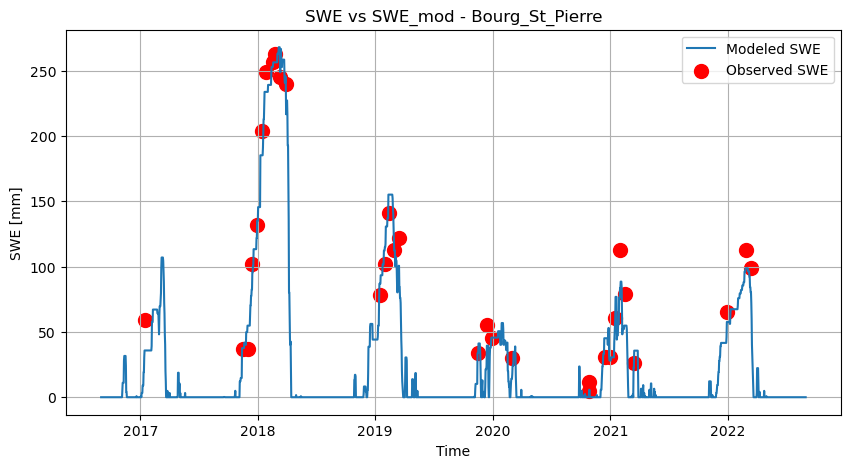


Processing station: Fionnay
HS input shape: (2191,)
Number of SWE observations: 57


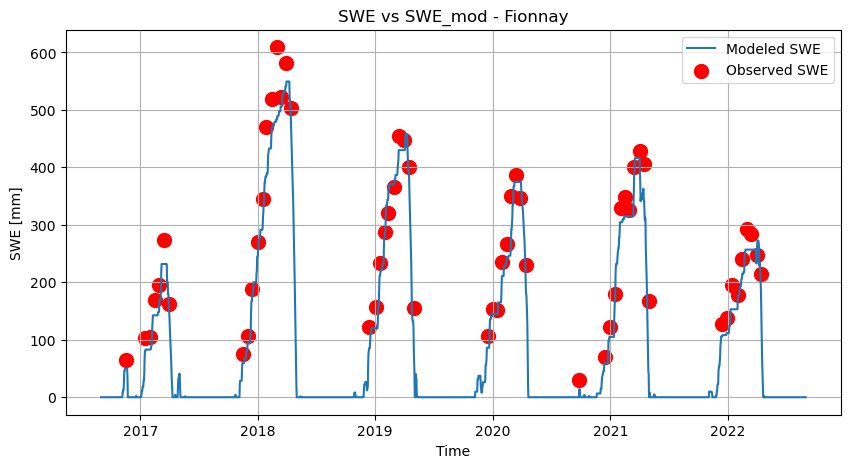


Processing station: Grimentz
HS input shape: (2191,)
Number of SWE observations: 0


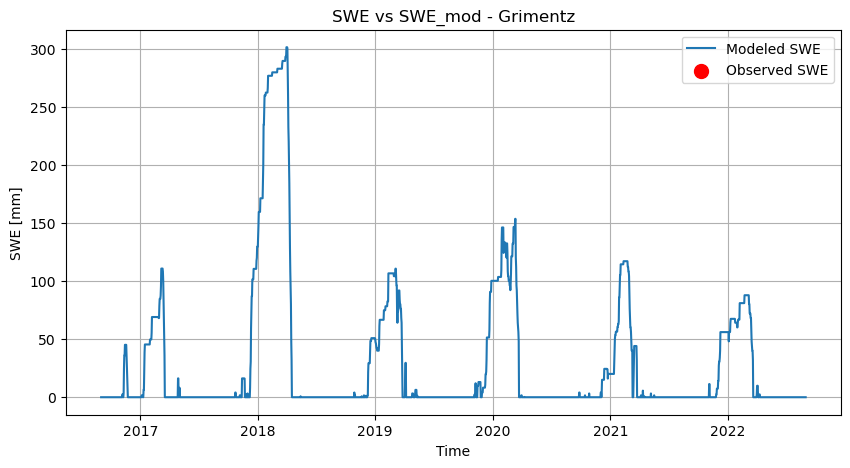


Processing station: Lauchernalp
HS input shape: (2191,)
Number of SWE observations: 0


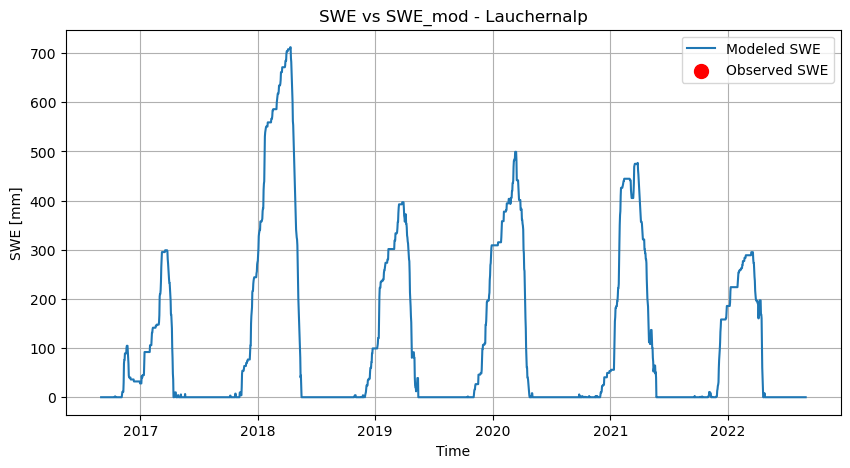


Processing station: Montana
HS input shape: (2191,)
Number of SWE observations: 0


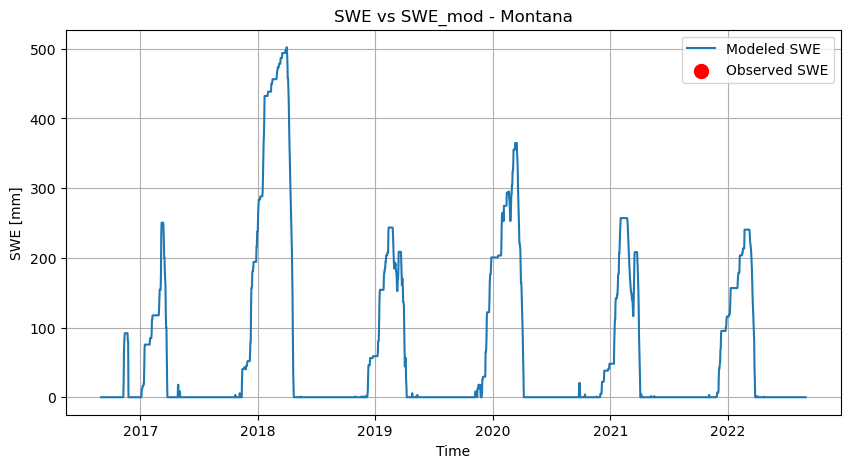


Processing station: Muenster
HS input shape: (2191,)
Number of SWE observations: 41


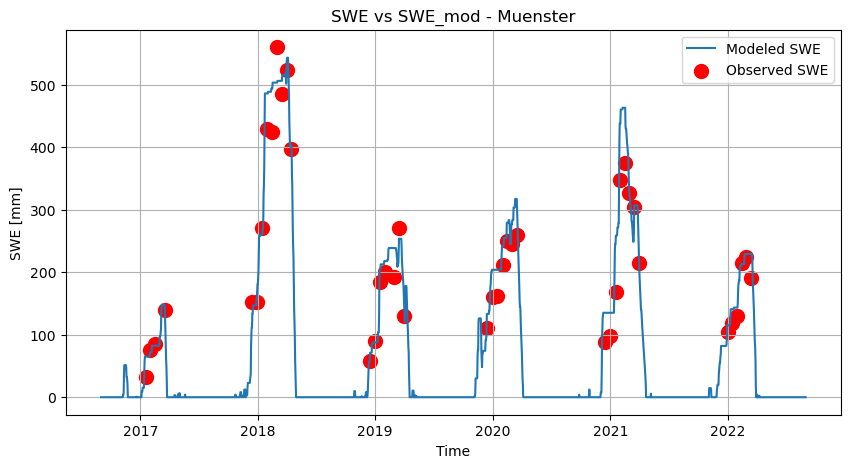


Processing station: Saas_Fee
HS input shape: (2191,)
Number of SWE observations: 40


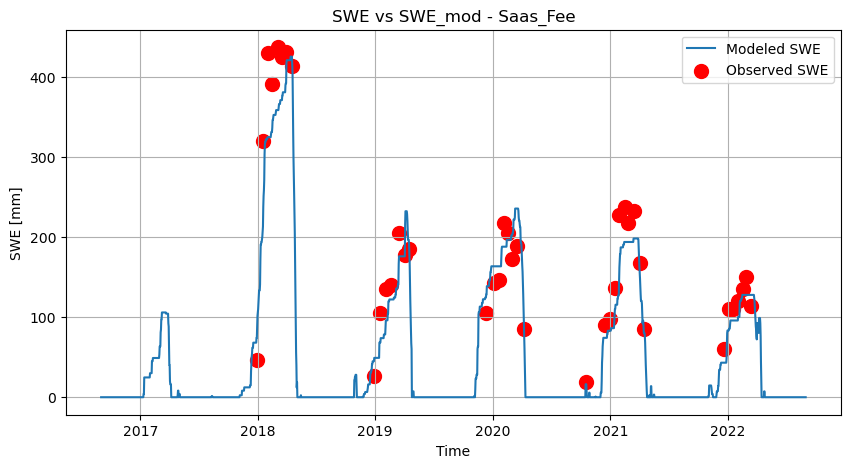


Processing station: Simplon_Dorf
HS input shape: (2191,)
Number of SWE observations: 0


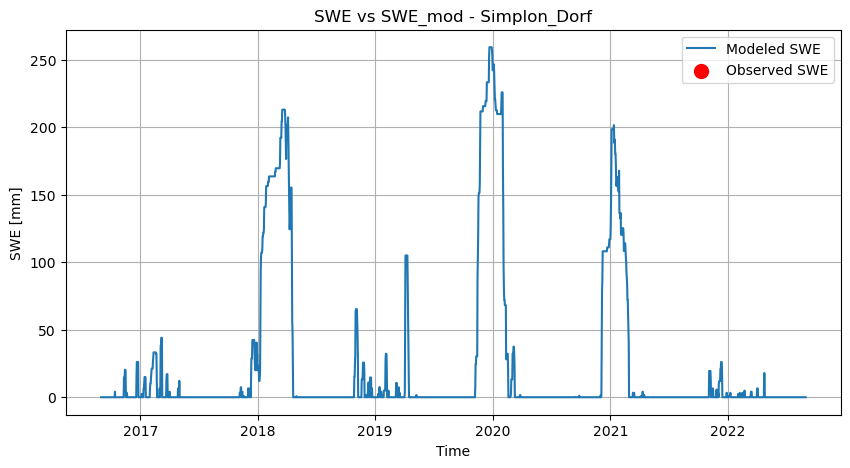


Processing station: Ulrichen
HS input shape: (2191,)
Number of SWE observations: 47


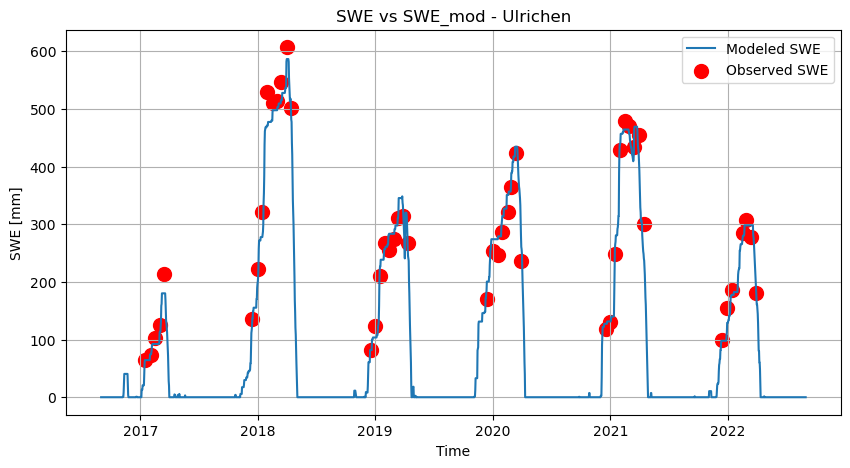


Processing station: Wiler
HS input shape: (2191,)
Number of SWE observations: 38


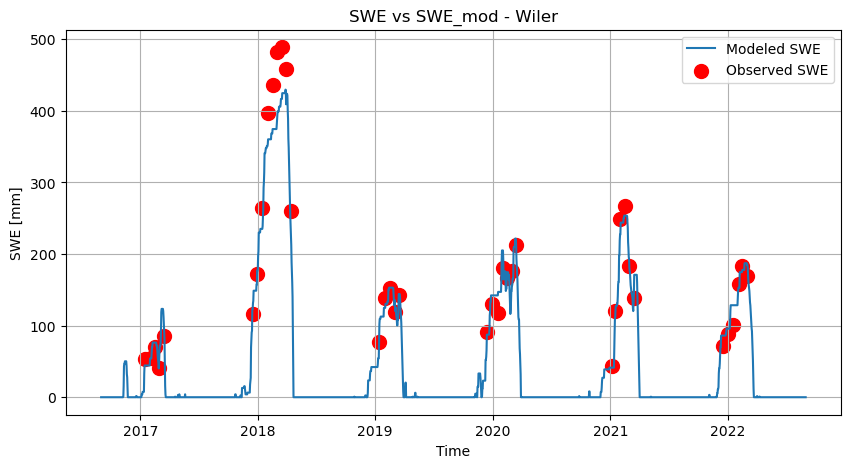


Processing station: Bivio
HS input shape: (2191,)
Number of SWE observations: 58


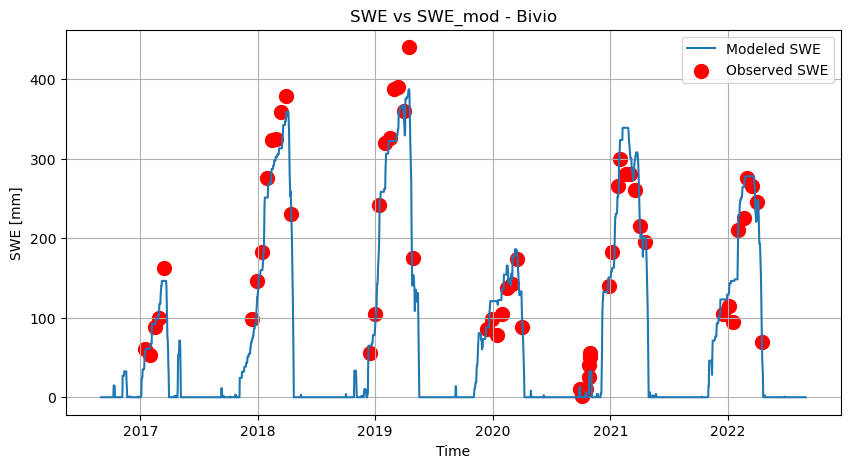


Processing station: Davos_Flueelastr
HS input shape: (2191,)
Number of SWE observations: 51


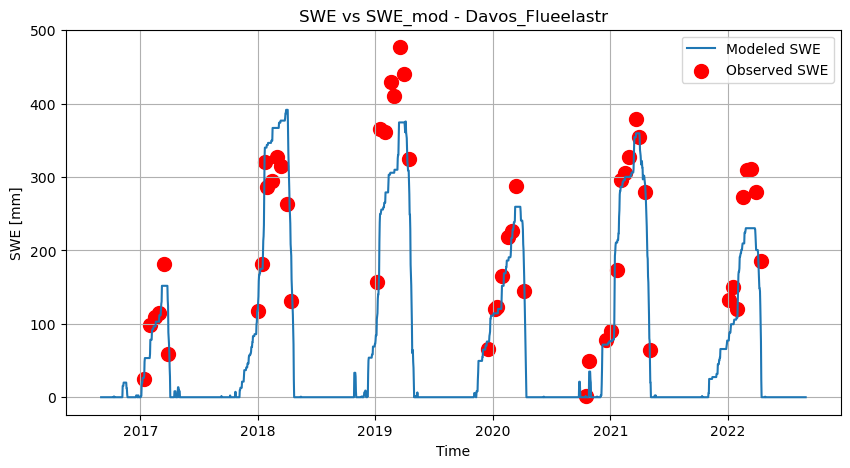


Processing station: Juf
HS input shape: (2191,)
Number of SWE observations: 69


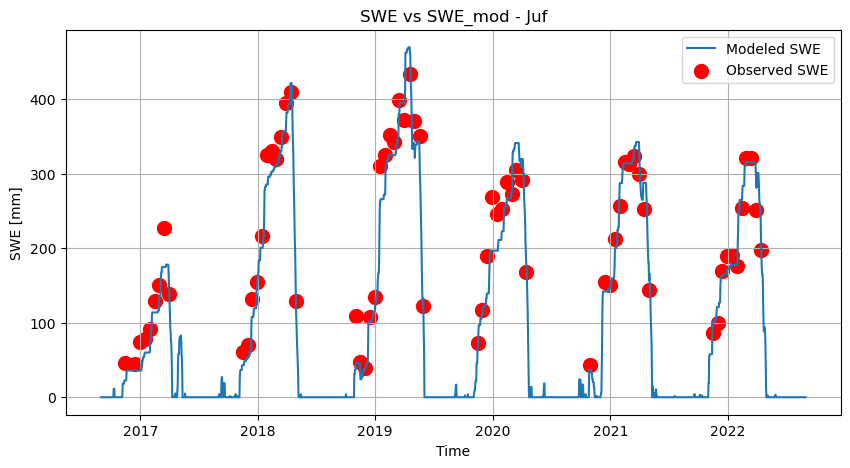


Processing station: Obersaxen
HS input shape: (2191,)
Number of SWE observations: 0


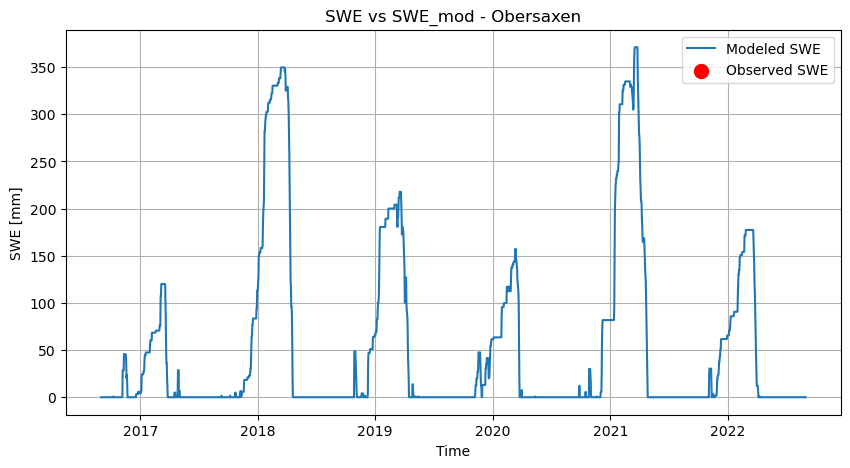


Processing station: Pusserein
HS input shape: (2191,)
Number of SWE observations: 0


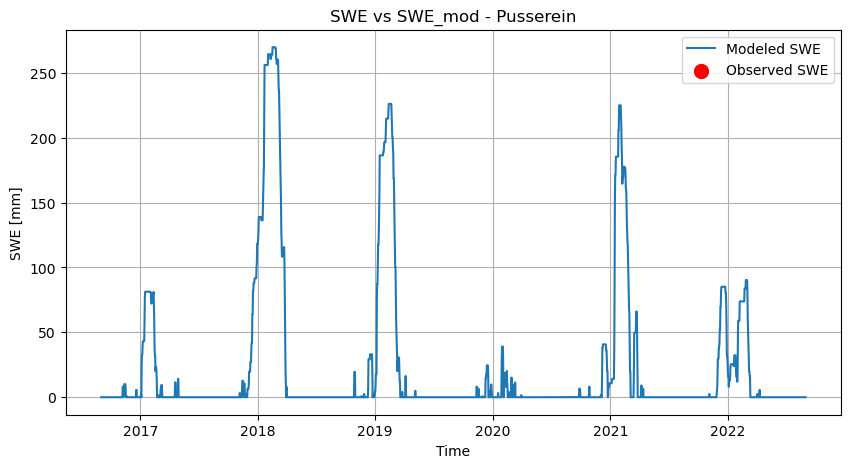


Processing station: St_Antoenien
HS input shape: (2191,)
Number of SWE observations: 0


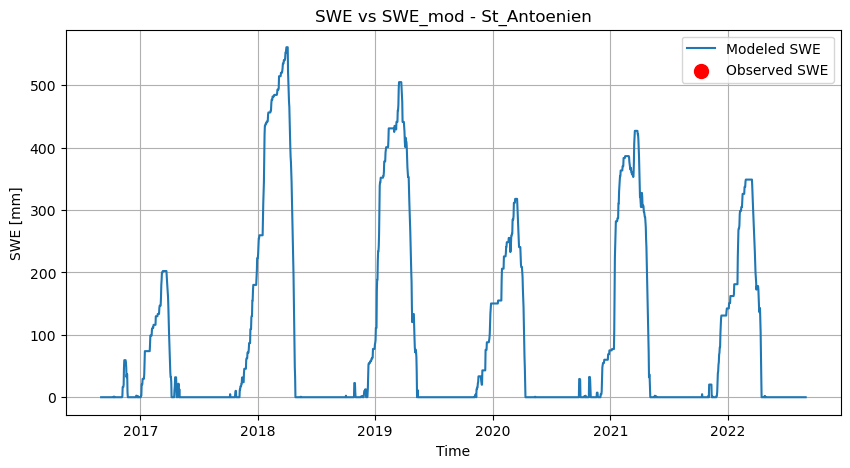


Processing station: Sedrun
HS input shape: (2191,)
Number of SWE observations: 52


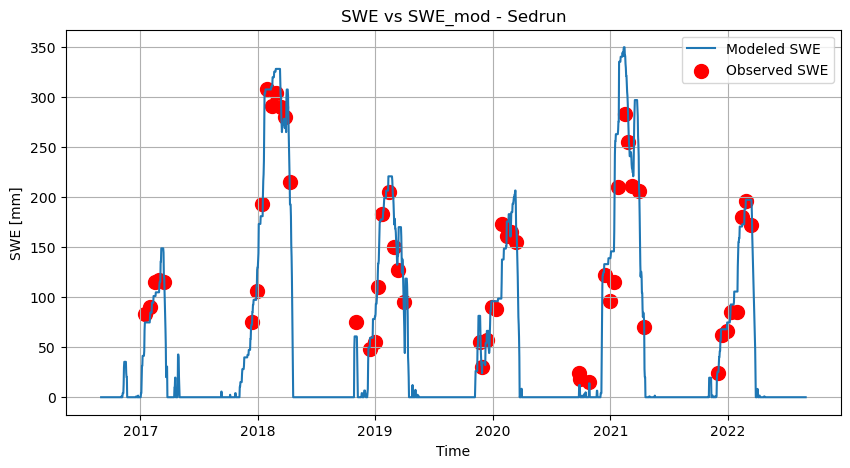


Processing station: Spluegen
HS input shape: (2191,)
Number of SWE observations: 41


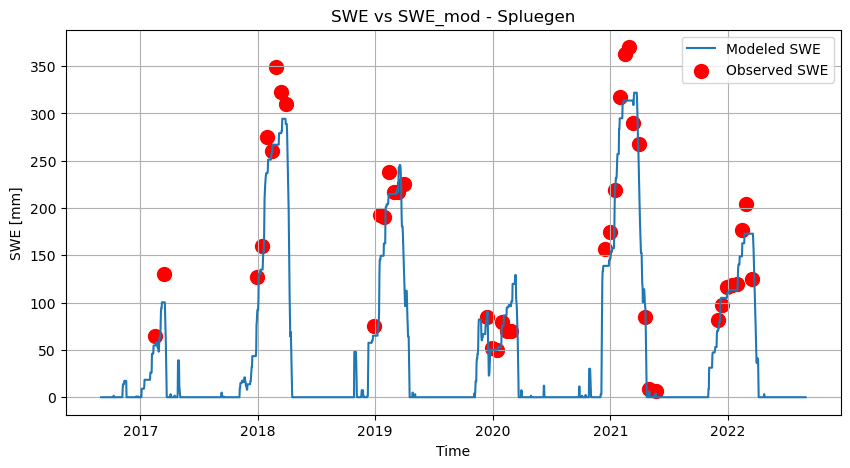


Processing station: Vals
HS input shape: (2191,)
Number of SWE observations: 0


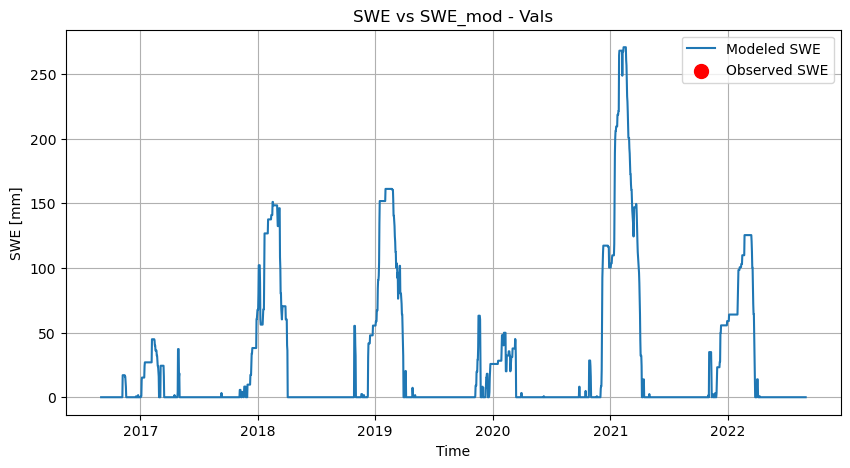


Processing station: Weisfluh_Joch
HS input shape: (2191,)
Number of SWE observations: 103


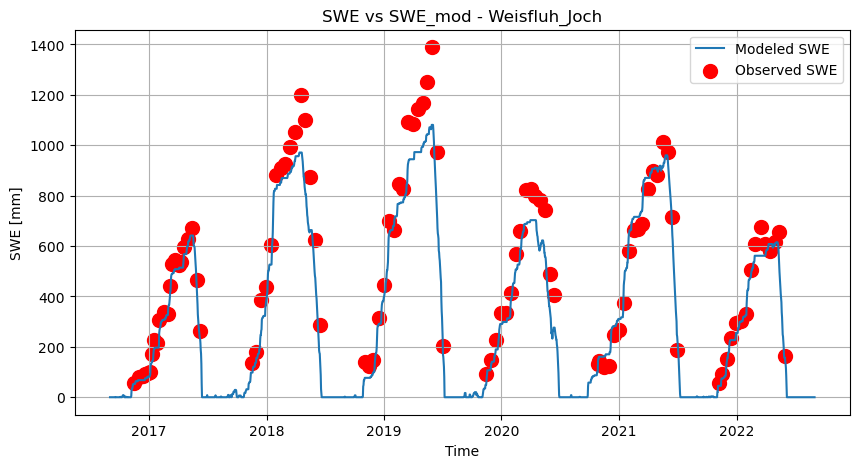


Processing station: Bosco_Gurin
HS input shape: (2191,)
Number of SWE observations: 0


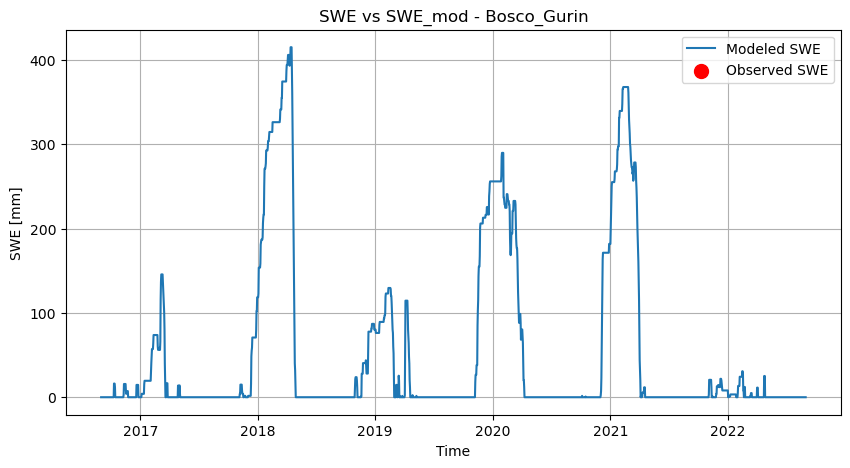


Processing station: San_Bernadino
HS input shape: (2191,)
Number of SWE observations: 35


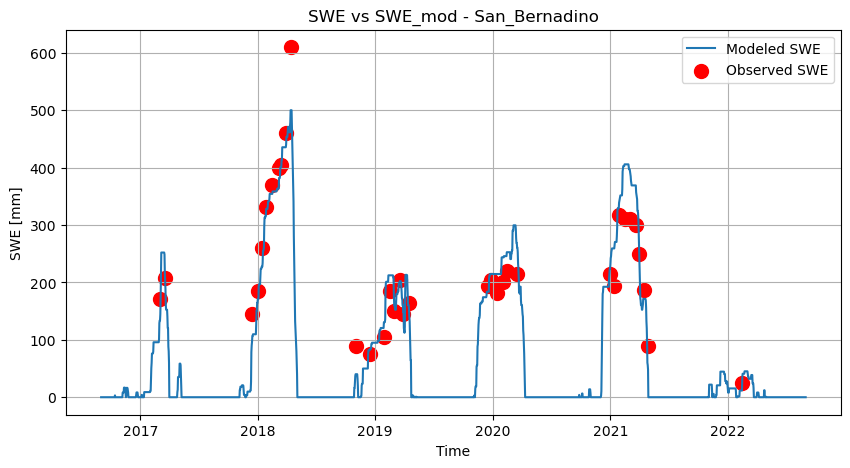


Processing station: Maloja
HS input shape: (2191,)
Number of SWE observations: 66


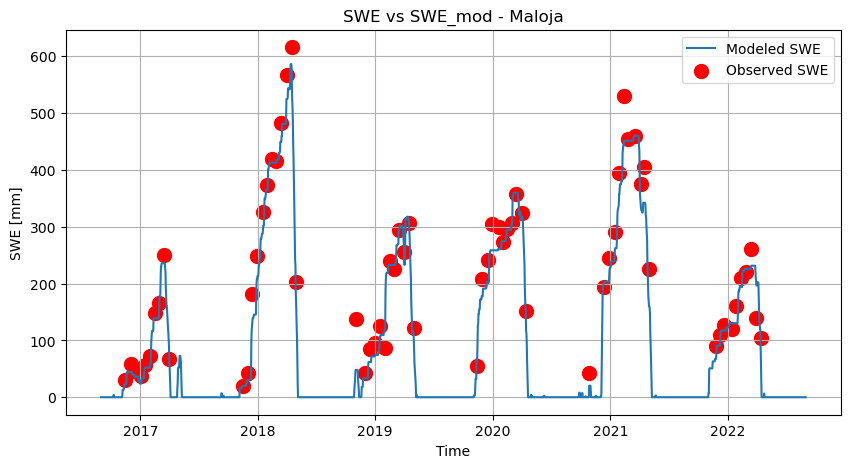


Processing station: Sankt_Moritz
HS input shape: (2191,)
Number of SWE observations: 0


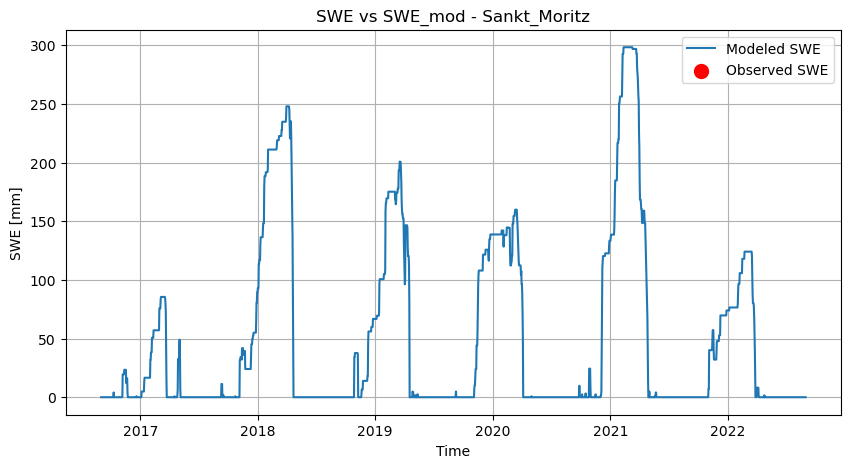


Processing station: Samnaun
HS input shape: (2191,)
Number of SWE observations: 43


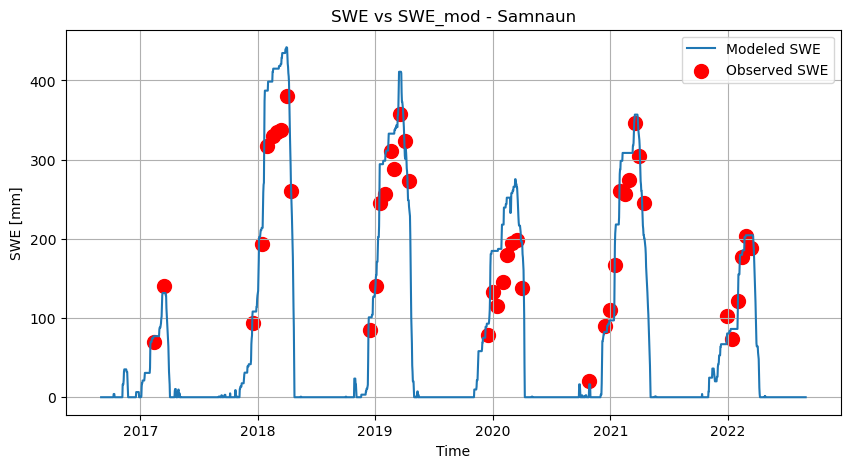


Processing station: Zuoz
HS input shape: (2191,)
Number of SWE observations: 45


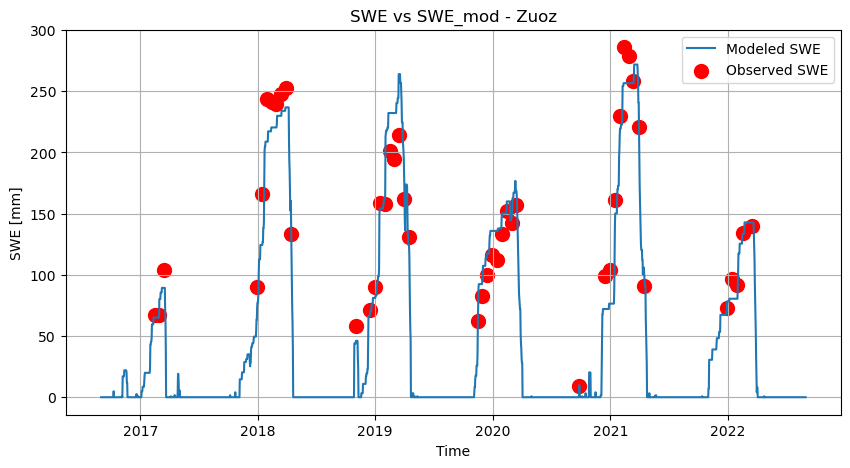

              station  n_obs
0           Adelboden     32
1              Gadmen      0
2    Grindelwald_Bort      0
3              Gsteig     52
4           Gantrisch     53
5              Leysin      0
6             Muerren     54
7        Saanenmoeser      0
8              Wengen      0
9            Srenberg      0
10              Stoos     52
11          Braunwald     52
12             Malbun     45
13  St_Margrethenberg      0
14               Binn      0
15    Bourg_St_Pierre     31
16            Fionnay     57
17           Grimentz      0
18        Lauchernalp      0
19            Montana      0
20           Muenster     41
21           Saas_Fee     40
22       Simplon_Dorf      0
23           Ulrichen     47
24              Wiler     38
25              Bivio     58
26   Davos_Flueelastr     51
27                Juf     69
28          Obersaxen      0
29          Pusserein      0
30       St_Antoenien      0
31             Sedrun     52
32           Spluegen     41
33            

In [17]:
# Load dataset
Mag25_data = xr.open_dataset("calibration/calibration_data/raw_data/Mag25/SLF_dataset/Mag25_all.nc")

# Create copy of original dataset
Mag25_data_with_SWE = Mag25_data.copy()

# Add empty SWE_mod variable for all stations
Mag25_data_with_SWE["SWE_mod"] = xr.full_like(Mag25_data_with_SWE["HS"], np.nan)

# Store number of observed SWE measurements per station
obs_counts = []

# Get all station names
station_list = Mag25_data["station"].values

for station_name in station_list:
    print(f"\nProcessing station: {station_name}")

    # Select one station and convert to pandas Series
    idata = Mag25_data["HS"].transpose("time", "station").sel(station=station_name).to_pandas()

    print(f"HS input shape: {idata.shape}")

    # Run DeltaSNOW model
    swe_results = pyds.swe_deltasnow(
        idata,
        hs_input_unit="m",
        swe_output_unit="mm",
        output_series_name="SWE_mod"
    )

    # Check shape
    assert swe_results.shape[0] == Mag25_data.sizes["time"]

    # Insert modeled values for this station
    Mag25_data_with_SWE["SWE_mod"].loc[dict(station=station_name)] = swe_results.values

    # Count available observed SWE measurements
    swe_obs = Mag25_data_with_SWE["SWE"].sel(station=station_name)
    n_obs = swe_obs.notnull().sum().item()
    print(f"Number of SWE observations: {n_obs}")

    obs_counts.append({
        "station": station_name,
        "n_obs": n_obs
    })

    # Plot observed SWE as scatter and modeled SWE as line
    plt.figure(figsize=(10, 5))

    plt.scatter(
        Mag25_data_with_SWE["time"].values,
        Mag25_data_with_SWE["SWE"].sel(station=station_name).values,
        s=100,
        color="r",
        label="Observed SWE"
    )

    plt.plot(
        Mag25_data_with_SWE["time"].values,
        Mag25_data_with_SWE["SWE_mod"].sel(station=station_name).values,
        label="Modeled SWE"
    )

    plt.xlabel("Time")
    plt.ylabel("SWE [mm]")
    plt.title(f"SWE vs SWE_mod - {station_name}")
    plt.legend()
    plt.grid(True)
    #plt.savefig("HNW_validation/HS2SWE_HNW/viz_out" + f"/{station_name}_SWE_comparison.png")
    plt.show()

# Create summary table
obs_counts_df = pd.DataFrame(obs_counts)
print(obs_counts_df)

# Creat HNW_mod Data

In [18]:
# Calculate day-to-day SWE increase
HNW_mod = Mag25_data_with_SWE["SWE_mod"].diff(dim="time")

# Clip negative values to 0
HNW_mod = HNW_mod.clip(min=0)

# Reindex back to the original time axis
HNW_mod = HNW_mod.reindex(time=Mag25_data_with_SWE["time"])

# Add to dataset
Mag25_data_with_SWE["HNW_mod"] = HNW_mod

In [ ]:
all_df = Mag25_data_with_SWE[["HNW", "HNW_mod"]].to_dataframe().reset_index()
all_df = all_df.rename(columns={
    "HNW": "HNW_obs",
    "HNW_mod": "HNW_mod"
})


,time,station,HNW_obs,HNW_mod
0,2016-09-01 06:00:00,Adelboden,NaN,NaN
1,2016-09-01 06:00:00,Gadmen,NaN,NaN
2,2016-09-01 06:00:00,Grindelwald_Bort,NaN,NaN
3,2016-09-01 06:00:00,Gsteig,NaN,NaN
4,2016-09-01 06:00:00,Gantrisch,NaN,NaN
...,...,...,...,...
89826,2022-08-31 06:00:00,San_Bernadino,NaN,0.0
89827,2022-08-31 06:00:00,Maloja,NaN,0.0
89828,2022-08-31 06:00:00,Sankt_Moritz,NaN,0.0
89829,2022-08-31 06:00:00,Samnaun,NaN,0.0


N        = 1157
RMSE     = 41.393
Bias     = -9.932
PBIAS    = -0.04
R²       = 0.946


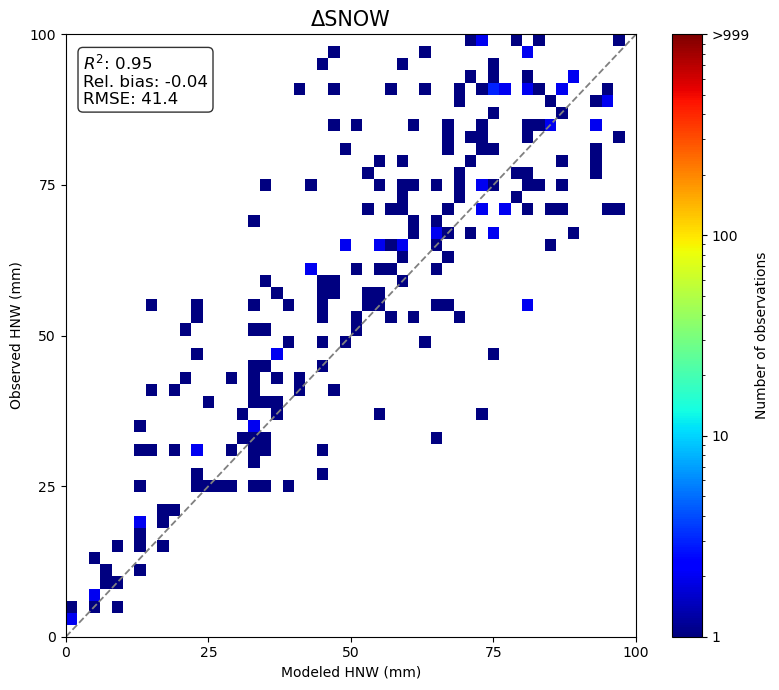

{'N': 1157,
 'RMSE': 41.39265759192609,
 'Bias': -9.931719650032573,
 'PBIAS': -0.04362013182492305,
 'R2': 0.9463178822058618}

In [22]:
all_df_swe = Mag25_data_with_SWE[["SWE", "SWE_mod"]].to_dataframe().reset_index()
all_df_swe = all_df_swe.rename(columns={
    "SWE": "SWE_obs",
    "SWE_mod": "SWE_mod"
})

val_helper.validate_hnw(all_df_swe, obs_col= "SWE_obs", mod_col= "SWE_mod")

N        = 36487
RMSE     = 3.024
Bias     = -0.363
PBIAS    = -0.17
R²       = 0.826


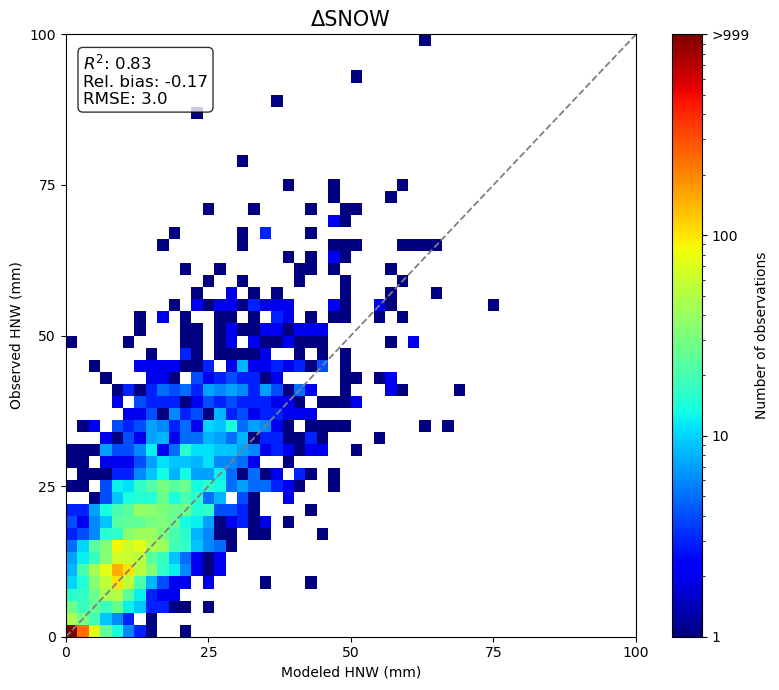

{'N': 36487,
 'RMSE': 3.0235477488711466,
 'Bias': -0.3625076676619257,
 'PBIAS': -0.17120098978734755,
 'R2': 0.8260168582334927}

In [20]:
val_helper.validate_hnw(all_df, obs_col= "HNW_obs", mod_col= "HNW_mod")

In [21]:
# Save output dataset
Mag25_data_with_SWE.to_netcdf("HNW_validation/dSnow/validated_data/Mag25_dSnow_all_stations_final.nc")